Vamos importar as bibliotecas fundamentais

In [19]:
import numpy as np
import pandas as pd
import spacy 
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

Vamos dar uma olhada pra ver se a gpu está rodando no kernel do Colab
Se tiver certinho, vamos continuar

In [2]:
!nvidia-smi

Thu May 21 13:09:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Vamos instalar o Spacy com o português

In [ ]:
%%capture
!python -m spacy download pt_core_news_lg

Testando o Wordcloud

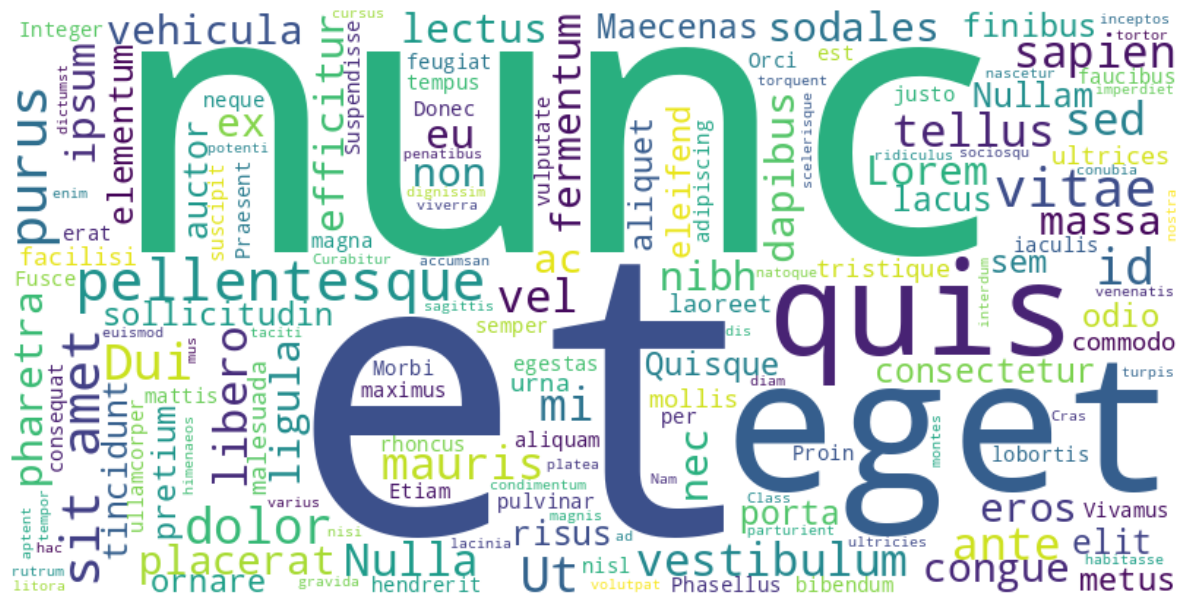

In [9]:
texto = """
Lorem ipsum dolor sit amet, consectetur adipiscing elit. Maecenas tincidunt libero ac vehicula vehicula. Ut non volutpat risus, vitae porta mi. Nunc bibendum feugiat libero a porta. Vivamus at tortor eu eros auctor placerat pharetra id risus. Sed in magna eget eros elementum vehicula. Donec quis elementum ante. Donec ac est vestibulum, pharetra ex non, gravida lacus. Class aptent taciti sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Nullam sollicitudin risus ante, quis hendrerit mi feugiat vitae.

Quisque sit amet finibus purus. Curabitur elementum sem ut libero euismod pretium. Vivamus vitae dignissim lectus. Suspendisse hendrerit, metus sit amet pulvinar venenatis, ante odio accumsan nibh, quis lobortis massa justo eu nunc. Morbi ut ullamcorper sapien. Duis dapibus sodales nunc id bibendum. Nullam mauris purus, congue vel diam semper, ornare fermentum purus. Pellentesque ullamcorper massa lorem, efficitur eleifend lorem efficitur eu. Nam sodales dolor vitae ex ultricies, quis pulvinar eros sollicitudin. Praesent aliquet purus in metus tristique condimentum. Vestibulum aliquet mollis lectus, ac sodales purus lobortis et. Nullam aliquam laoreet turpis, pretium rhoncus lectus pellentesque et. Cras et iaculis mi. Quisque sapien elit, ornare non ligula at, maximus congue ligula. Lorem ipsum dolor sit amet, consectetur adipiscing elit.

Ut facilisis, ligula eu egestas mollis, sem massa pharetra sem, et placerat dui dolor quis eros. Integer eget libero faucibus tellus consequat pellentesque eget at ipsum. Nunc nec mattis erat, sed tristique nibh. Nunc sed pellentesque neque. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Integer interdum eget nunc non commodo. Duis auctor mauris eget nulla consectetur sagittis et eget mauris. Maecenas ac mattis est. Duis lacinia vitae lectus quis tempus. Vestibulum in sapien quis nisl tempor suscipit. Suspendisse potenti.

Maecenas vehicula congue nunc laoreet consequat. Sed massa ex, placerat laoreet sapien sit amet, maximus egestas enim. Pellentesque pretium commodo mi. Quisque dapibus eget urna et malesuada. Etiam viverra purus vel urna vulputate, id semper dui finibus. Pellentesque nec ex a dolor eleifend ultrices. In hac habitasse platea dictumst. Phasellus tincidunt tellus dapibus ipsum fermentum, sed placerat mauris ultrices. Nulla pellentesque et nibh a ornare. Nulla facilisi. Phasellus vitae purus vel erat vestibulum vestibulum. Ut vel ultrices odio.

Proin dapibus tellus ut porta rutrum. Praesent pellentesque fermentum ligula a faucibus. Proin mi mauris, tincidunt at vulputate fermentum, sollicitudin et tellus. Duis eget magna lacus. Etiam vel tellus sit amet lacus rhoncus commodo. Fusce a orci quis nisi sodales eleifend. Nulla id suscipit nisl. Aliquam malesuada ante ante, nec aliquet nibh scelerisque vitae. In pharetra imperdiet dolor nec tristique. Morbi congue, nulla finibus mollis cursus, odio libero facilisis sapien, id malesuada urna neque sit amet metus. Fusce auctor tempus nunc, iaculis efficitur justo efficitur id.

"""

wc = WordCloud(width=800, height = 400, background_color='white').generate(texto)
plt.figure(figsize=(12,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

### Vamos agora importar a base de dados

Os textos das atas eu extraí de outro projeto que eu tenho

In [16]:
dados = pd.read_csv("atas_do_copom.csv")
dados = dados[["data", "texto"]]
dados

,data,texto
0,05/05/2026,"1. O ambiente externo permanece incerto, em fu..."
1,24/03/2026,"1. O ambiente externo tornou-se mais incerto, ..."
2,03/02/2026,1. O ambiente externo ainda se mantém incerto ...
3,16/12/2025,1. O ambiente externo ainda se mantém incerto ...
4,11/11/2025,1. O ambiente externo ainda se mantém incerto ...
5,23/09/2025,1. O ambiente externo se mantém incerto em fun...
6,05/08/2025,1. O ambiente externo está mais adverso e ince...
7,24/06/2025,1. O ambiente externo mantém-se adverso e part...
8,13/05/2025,1. O ambiente externo mostra-se adverso e part...
9,25/03/2025,1. O ambiente externo permanece desafiador em ...


Temos agora nossa base importada direitinho. O que vamos fazer é apenas textar o wordcloud em cima de todos os textos que extraímos.

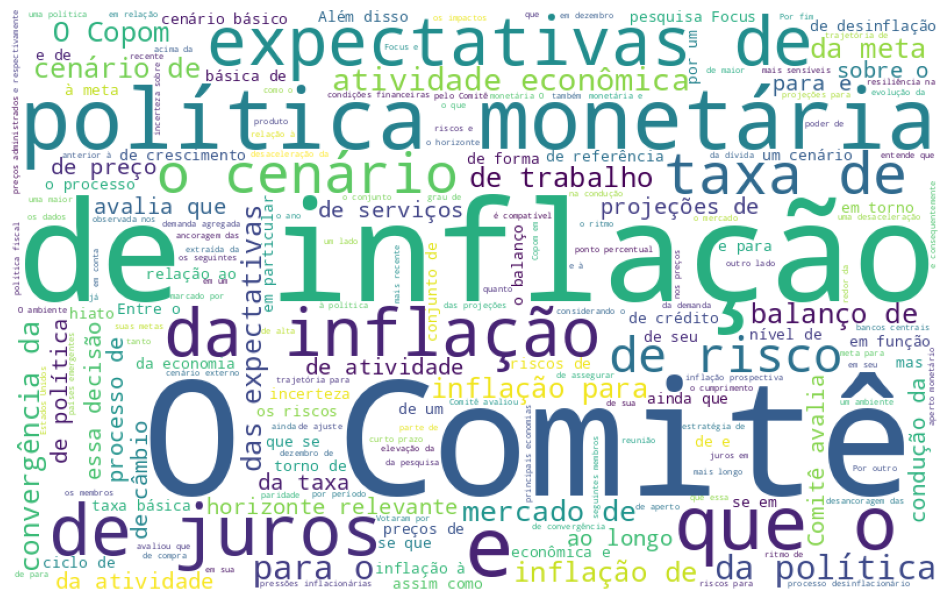

In [27]:
texto_teste = ' '.join(dados['texto'].dropna().astype(str))

wc = WordCloud(width=800, height=500, background_color='white').generate(texto_teste)

plt.figure(figsize=(12,8))
plt.imshow(wc)
plt.axis('off')
plt.show()

### Vamos programar o lemmetizador

Como podemos ver na imagem, tivemos muitas stopwords e palavras que não serão muito úteis em uma análise mais fundamentada, como "O Comitê", "inflação", "inflação de", "de juros", etc...e outras _stopwords_, que é o nome de damos a preposições, conjunções, artigos, etc... (de, o, para, onde, da, assim, etc...)

Imediatamente abaixo, iremos configurar a função de lemmetizar e testá-la, ainda, iremos retornar as stopwrods em português.

In [20]:
nlp = spacy.load("pt_core_news_lg")
def lemmetizar(string):
    string = re.sub("[^A-zÀ-ú0-9]+", ' ', string).lower()
    doc = nlp(string)
    return " ".join([token.lemma_ for token in doc if not token.is_stop])

lemmetizar("O ambiente externo continua insuportável")

'ambiente externo continuar insuportável'